# GraphProject — Benchmark Results

Comparative benchmarks of the graph storage structures in this repository:

- **NaiveGraph** — `unordered_map` + `vector` adjacency list
- **CBListGraph** — cache-line-aligned chunked linked list (64-byte / 192-byte chunks)
- **CGGGraph** — GastCoCo CBList storage (small chunks + B+ tree per vertex, GTChain)
- **DynamicCSRGraph** — CSR rebuilt on mutation
- **StaticCSRGraph** — immutable CSR (read-optimised)
- **RawGraph** — flat edge list (linear-scan baseline, run at smaller sizes)

All comparison benchmarks use the **strict** generator (no duplicate edges, no
self-loops) so every structure ingests an identical edge set.

Run order: this notebook loads `results/results_advanced.json`. To regenerate
the numbers, build the project and set `RUN_BENCHMARKS = True` in the next cell
(or run `./benchmarks/run_benchmarks --benchmark_out=... --benchmark_out_format=json`).

In [ ]:
import os, re, json, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_BENCHMARKS = False   # set True to (re)run the compiled binary before plotting
MIN_TIME = "0.02s"       # only used when RUN_BENCHMARKS is True

HERE = Path.cwd()
ROOT = HERE if (HERE / "results").exists() else HERE.parent
JSON_PATH = ROOT / "results" / "results_advanced.json"
BIN_PATH  = ROOT / "build" / "benchmarks" / "run_benchmarks"

if RUN_BENCHMARKS and BIN_PATH.exists():
    print("Running", BIN_PATH, "...")
    subprocess.run([str(BIN_PATH),
                    f"--benchmark_min_time={MIN_TIME}",
                    f"--benchmark_out={JSON_PATH}",
                    "--benchmark_out_format=json"], check=True)

print("Loading:", JSON_PATH)
raw = json.load(open(JSON_PATH))
print("context:", raw.get("context", {}).get("host_name", "?"),
      "| library:", raw.get("context", {}).get("library_version", "?"))


Loading: /home/petar/GraphProject/GraphProject/results/results_advanced.json
context: petar-laptop | library: ?


In [ ]:
# used dataframes
def parse(raw):
    rows = []
    for b in raw["benchmarks"]:
        if b.get("run_type") == "aggregate":
            continue
        name = b["name"]
        family = re.split(r"[<;/]", name, 1)[0]
        ms = re.search(r"<\s*([A-Za-z0-9_]+)", name)
        structure = ms.group(1) if ms else "—"
        mp = re.search(r"/(\d+)\b", name)
        param = int(mp.group(1)) if mp else None
        rows.append(dict(
            name=name, family=family, structure=structure, param=param,
            real_time=b.get("real_time"), cpu_time=b.get("cpu_time"),
            items_per_second=b.get("items_per_second"),
            bytes=b.get("bytes"), bytes_per_edge=b.get("bytes_per_edge"),
            edges=b.get("edges"),
        ))
    return pd.DataFrame(rows)

df = parse(raw)
print(df["family"].value_counts())
df.head()


family
BM_EdgeLookup                   23
BM_NeighborTraversal            23
BM_FullScan                     23
BM_BFS                          23
BM_Dijkstra                     23
BM_Uniform_BFS                  23
BM_RMAT_BFS                     23
BM_Grid_Dijkstra                23
BM_PointerChase                 23
BM_Density_Dijkstra             20
BM_Density_Scan                 20
BM_EdgeInsertion                18
BM_Memory                       18
BM_Polymorphism_Template_BFS     3
BM_Polymorphism_Virtual_BFS      3
BM_BigClass_Direct_BFS           2
BM_BigClass_External_BFS         2
Name: count, dtype: int64


,name,family,structure,param,real_time,cpu_time,items_per_second,bytes,bytes_per_edge,edges
0,"BM_EdgeInsertion<NaiveGraph<uint32_t, double>>...",BM_EdgeInsertion,NaiveGraph,1024,5.462667e+05,5.461368e+05,1.499991e+07,NaN,NaN,NaN
1,"BM_EdgeInsertion<NaiveGraph<uint32_t, double>>...",BM_EdgeInsertion,NaiveGraph,4096,2.511843e+06,2.511217e+06,1.304865e+07,NaN,NaN,NaN
2,"BM_EdgeInsertion<NaiveGraph<uint32_t, double>>...",BM_EdgeInsertion,NaiveGraph,16384,1.022881e+07,1.022536e+07,1.281832e+07,NaN,NaN,NaN
3,"BM_EdgeInsertion<NaiveGraph<uint32_t, double>>...",BM_EdgeInsertion,NaiveGraph,65536,4.128920e+07,4.128018e+07,1.270072e+07,NaN,NaN,NaN
4,"BM_EdgeInsertion<CBListGraph<uint32_t, double>...",BM_EdgeInsertion,CBListGraph,1024,1.920352e+05,1.920203e+05,4.266216e+07,NaN,NaN,NaN


In [ ]:
STRUCT_ORDER = ["StaticCSRGraph", "DynamicCSRGraph", "CSRGraph",
                "CBListGraph", "CGGGraph", "NaiveGraph", "RawGraph"]
PALETTE = {
    "StaticCSRGraph":  "#2563eb",
    "DynamicCSRGraph": "#0891b2",
    "CSRGraph":        "#0ea5e9",
    "CBListGraph":     "#16a34a",
    "CGGGraph":        "#9333ea",
    "NaiveGraph":      "#f59e0b",
    "RawGraph":        "#dc2626",
}
def color(s): return PALETTE.get(s, "#666666")
def structs_in(sub):
    present = [s for s in STRUCT_ORDER if s in set(sub["structure"])]
    return present + [s for s in sub["structure"].unique() if s not in STRUCT_ORDER]

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})

def line_vs_param(family, value="items_per_second", scale=1e6,
                  ylabel="M items / s", xlabel="Vertices (V)",
                  logx=True, logy=True, title=None):
    sub = df[df["family"] == family].dropna(subset=["param", value])
    if sub.empty:
        print("no data for", family); return
    fig, ax = plt.subplots(figsize=(8, 5))
    for s in structs_in(sub):
        d = sub[sub["structure"] == s].sort_values("param")
        ax.plot(d["param"], d[value] / scale, marker="o", label=s, color=color(s))
    if logx: ax.set_xscale("log", base=2)
    if logy: ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title or family); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 1. Edge insertion throughput

Cost of building each structure edge by edge (average degree 8). `DynamicCSRGraph`
rebuilds its CSR arrays on every insertion, so it is intentionally limited to
small sizes — its curve collapsing is the expected result, not a measurement error.

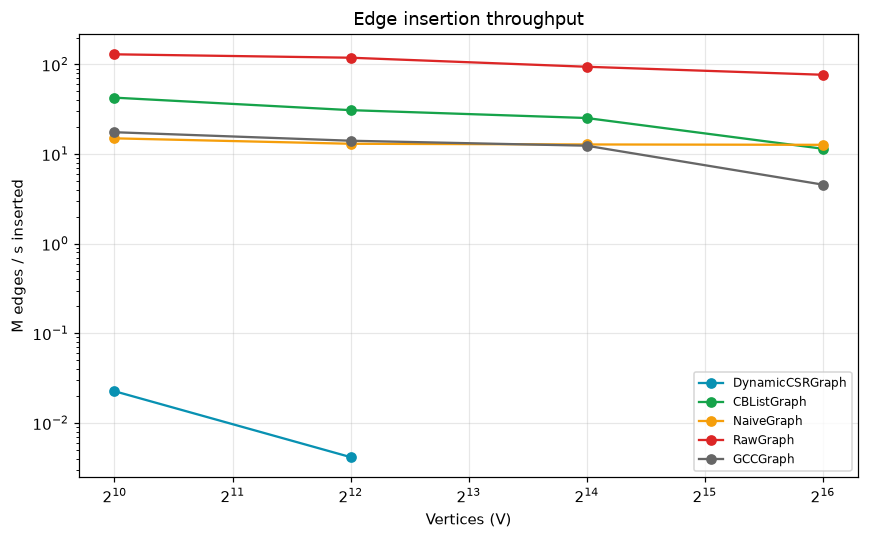

In [17]:
line_vs_param("BM_EdgeInsertion", ylabel="M edges / s inserted", title="Edge insertion throughput")

## 2. Read-only workloads vs graph size

Higher is better. Watch how the contiguous CSR layouts pull ahead on the
sequential **full scan**, and how `RawGraph` (linear edge-list scans) falls off
a cliff even at small sizes.

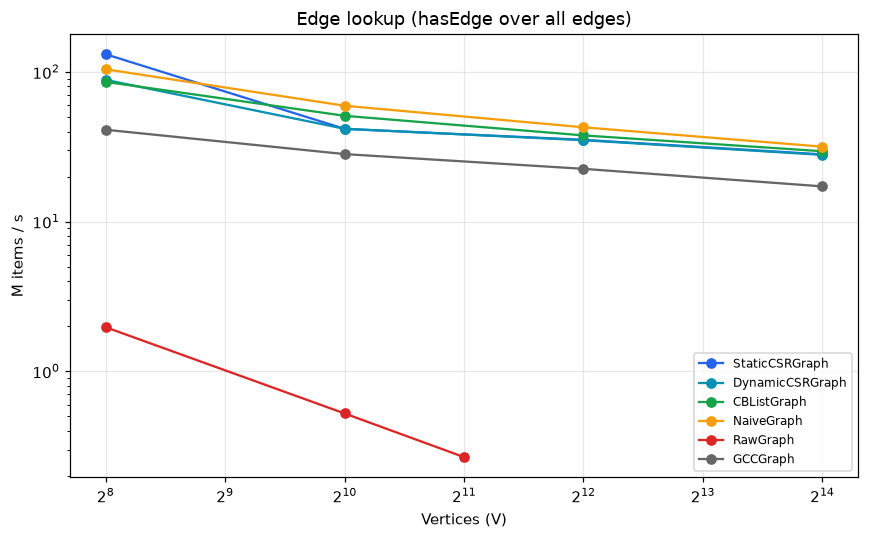

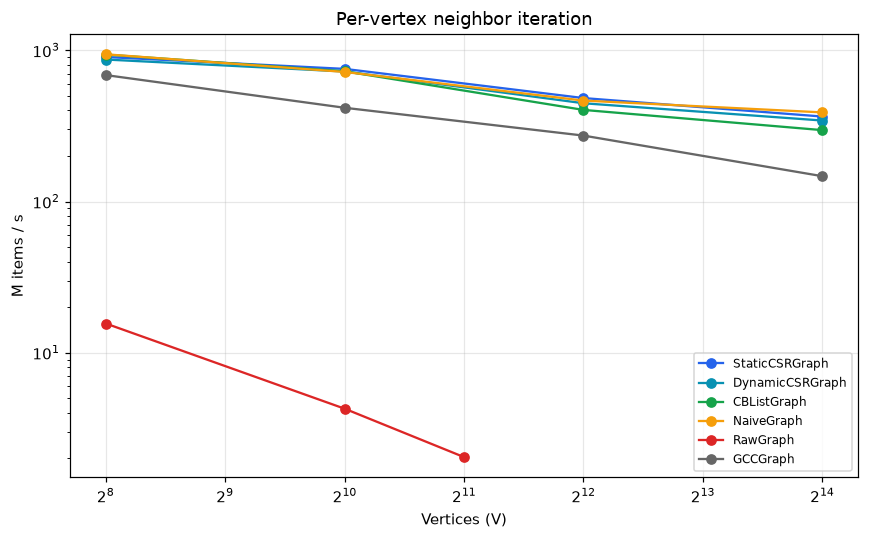

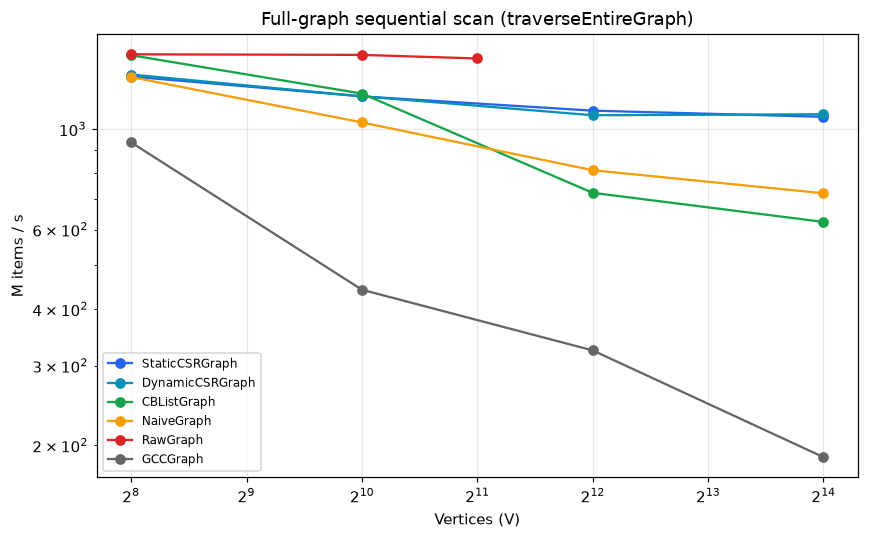

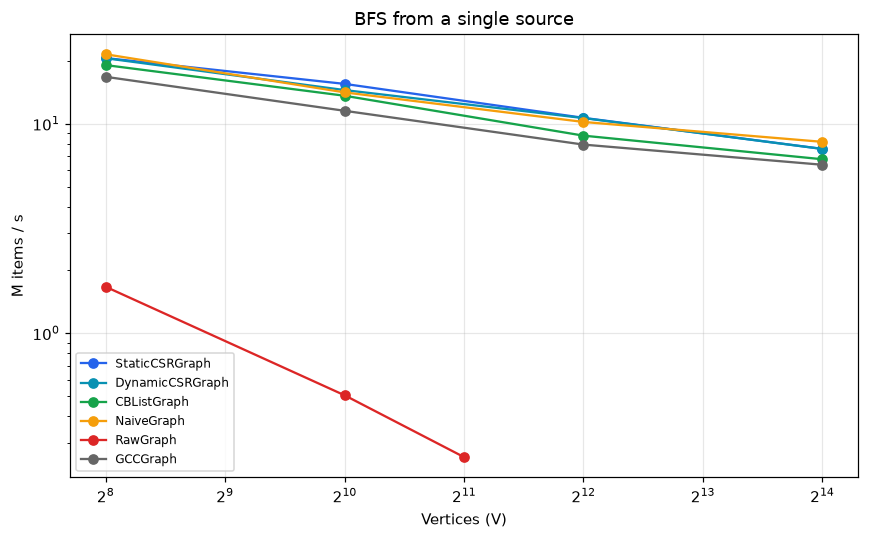

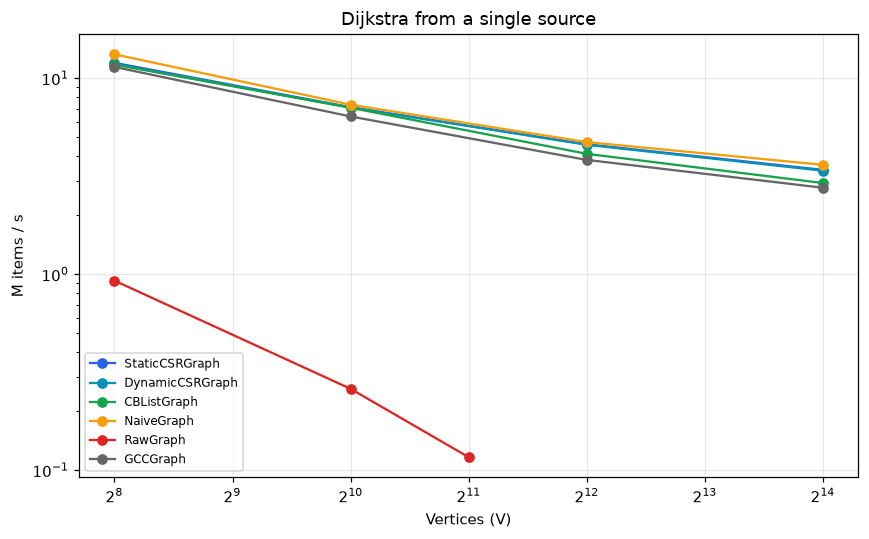

In [18]:
for fam, title in [
    ("BM_EdgeLookup", "Edge lookup (hasEdge over all edges)"),
    ("BM_NeighborTraversal", "Per-vertex neighbor iteration"),
    ("BM_FullScan", "Full-graph sequential scan (traverseEntireGraph)"),
    ("BM_BFS", "BFS from a single source"),
    ("BM_Dijkstra", "Dijkstra from a single source"),
]:
    line_vs_param(fam, title=title)


## 3. Density sweep

Fixed vertex count (4096), average degree on the x-axis: how each structure
scales from sparse to dense graphs.

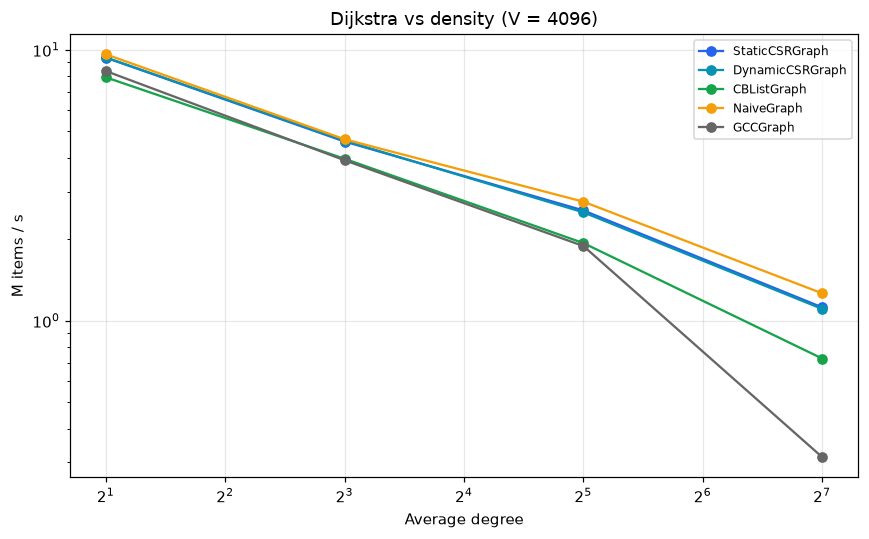

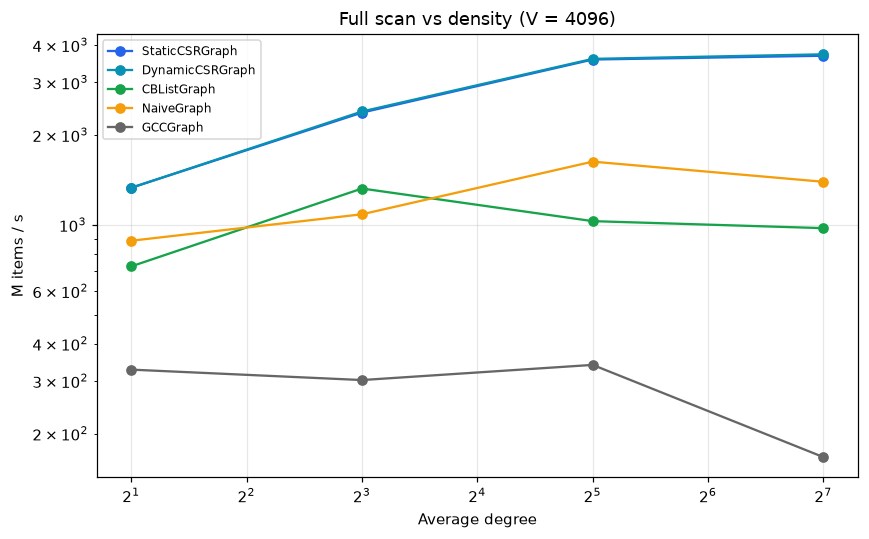

In [19]:
line_vs_param("BM_Density_Dijkstra", xlabel="Average degree",
              title="Dijkstra vs density (V = 4096)")
line_vs_param("BM_Density_Scan", xlabel="Average degree",
              title="Full scan vs density (V = 4096)")


## 4. Topologies

Same size, different graph shape: uniform random, scale-free (R-MAT), and a 2D
grid mesh. Bars compare structures at the largest common size.

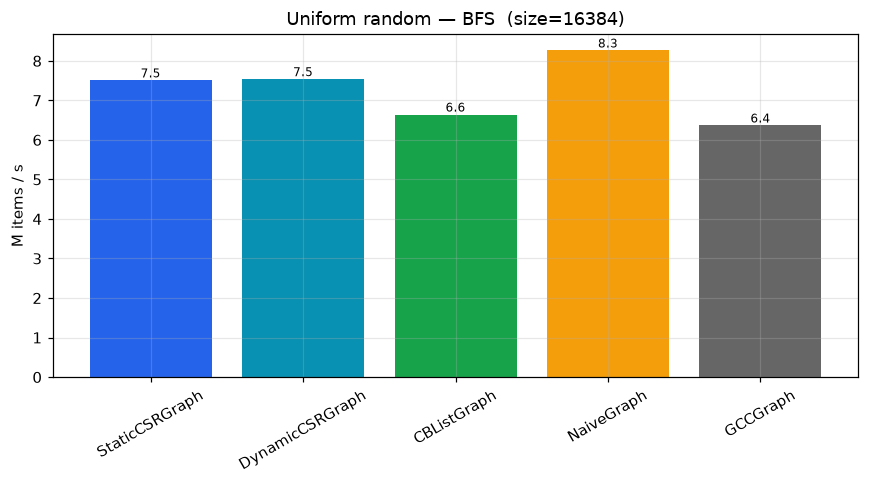

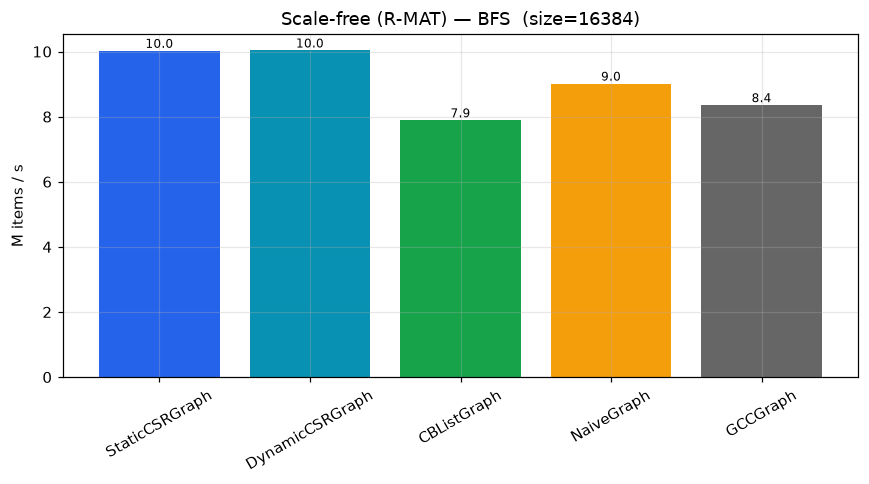

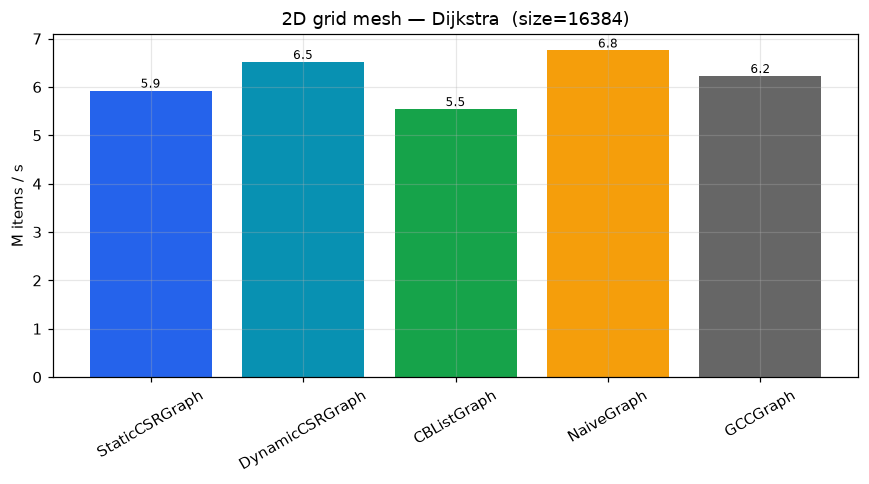

In [20]:
def topo_bars(family, metric="items_per_second", scale=1e6, ylabel="M items / s", title=None):
    sub = df[df["family"] == family].dropna(subset=["param", metric])
    if sub.empty:
        print("no data for", family); return
    size = sub["param"].max()
    at = sub[sub["param"] == size]
    order = structs_in(at)
    vals = [at[at["structure"] == s][metric].mean() / scale for s in order]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(order, vals, color=[color(s) for s in order])
    ax.set_ylabel(ylabel); ax.set_title((title or family) + f"  (size={int(size)})")
    ax.tick_params(axis="x", rotation=30)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout(); plt.show()

topo_bars("BM_Uniform_BFS", title="Uniform random — BFS")
topo_bars("BM_RMAT_BFS", title="Scale-free (R-MAT) — BFS")
topo_bars("BM_Grid_Dijkstra", title="2D grid mesh — Dijkstra")


## 5. Pointer-chasing latency

A single closed cycle (out-degree 1). Following the chain is dominated by memory
latency, so this isolates the cache behaviour of each layout. Lower ns/hop is
better.

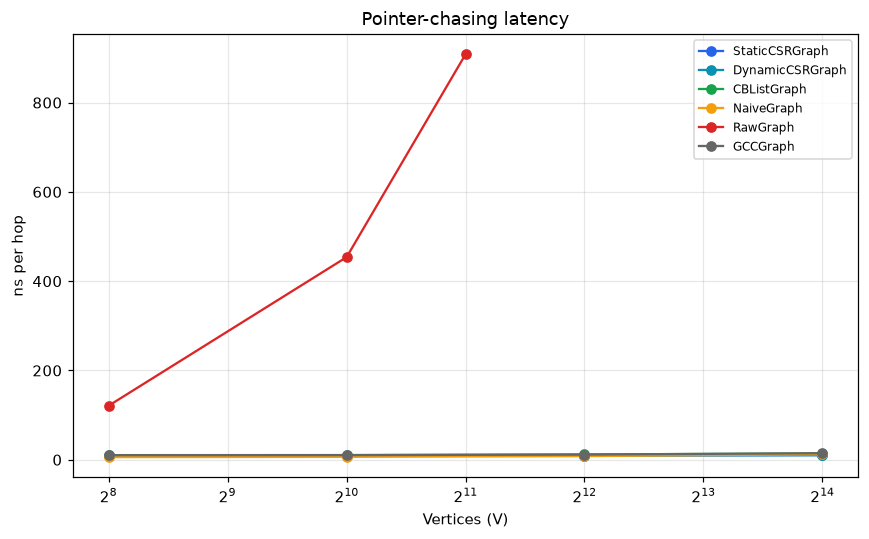

In [21]:
sub = df[df["family"] == "BM_PointerChase"].dropna(subset=["param", "real_time"]).copy()
sub["ns_per_hop"] = sub["real_time"] / sub["param"]
fig, ax = plt.subplots(figsize=(8, 5))
for s in structs_in(sub):
    d = sub[sub["structure"] == s].sort_values("param")
    ax.plot(d["param"], d["ns_per_hop"], marker="o", label=s, color=color(s))
ax.set_xscale("log", base=2)
ax.set_xlabel("Vertices (V)"); ax.set_ylabel("ns per hop")
ax.set_title("Pointer-chasing latency"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 6. Memory footprint

Edge-storage bytes only (the shared vertex id↔index maps are excluded so the
structures are comparable). Left: bytes per stored edge. Right: total edge-storage
bytes vs graph size.

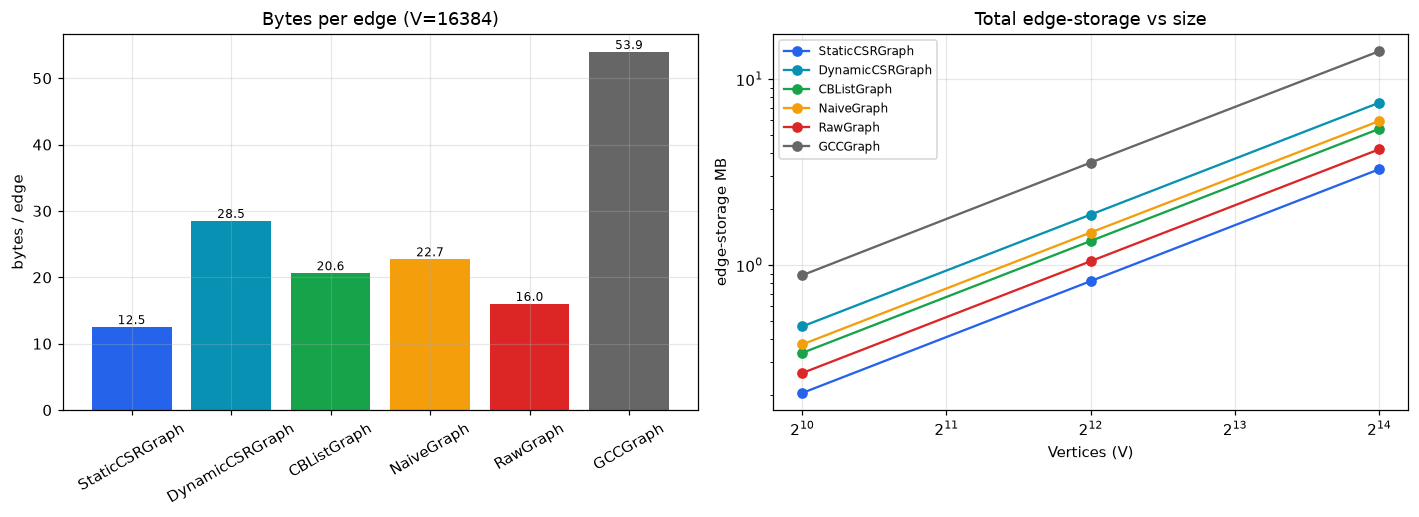

In [22]:
mem = df[df["family"] == "BM_Memory"].dropna(subset=["param", "bytes_per_edge"])
order = structs_in(mem)
big = mem["param"].max()
at = mem[mem["param"] == big]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
vals = [at[at["structure"] == s]["bytes_per_edge"].mean() for s in order]
axes[0].bar(order, vals, color=[color(s) for s in order])
axes[0].set_ylabel("bytes / edge"); axes[0].set_title(f"Bytes per edge (V={int(big)})")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(vals):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=8)

for s in order:
    d = mem[mem["structure"] == s].sort_values("param")
    axes[1].plot(d["param"], d["bytes"] / 1e6, marker="o", label=s, color=color(s))
axes[1].set_xscale("log", base=2); axes[1].set_yscale("log")
axes[1].set_xlabel("Vertices (V)"); axes[1].set_ylabel("edge-storage MB")
axes[1].set_title("Total edge-storage vs size"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 7. Template (CRTP) vs virtual dispatch

Same CSR read workload (BFS), once through static CRTP dispatch and once through
a `virtual` base pointer. The gap is the cost of runtime polymorphism.

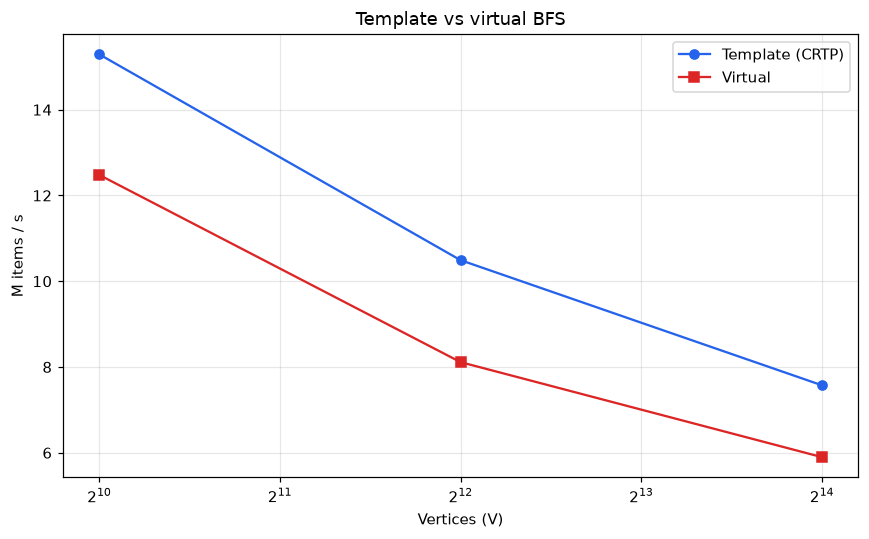

 param  overhead_%
  1024   22.530423
  4096   29.309368
 16384   28.404843


In [23]:
t = df[df["family"] == "BM_Polymorphism_Template_BFS"].dropna(subset=["param"]).sort_values("param")
v = df[df["family"] == "BM_Polymorphism_Virtual_BFS"].dropna(subset=["param"]).sort_values("param")
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t["param"], t["items_per_second"] / 1e6, marker="o", label="Template (CRTP)", color="#2563eb")
ax.plot(v["param"], v["items_per_second"] / 1e6, marker="s", label="Virtual", color="#dc2626")
ax.set_xscale("log", base=2)
ax.set_xlabel("Vertices (V)"); ax.set_ylabel("M items / s")
ax.set_title("Template vs virtual BFS"); ax.legend()
plt.tight_layout(); plt.show()

merged = t.merge(v, on="param", suffixes=("_tmpl", "_virt"))
merged["overhead_%"] = 100 * (merged["items_per_second_tmpl"] / merged["items_per_second_virt"] - 1)
print(merged[["param", "overhead_%"]].to_string(index=False))


## 8. BigClass: direct vs external vertex storage

Storing a heavy 128-byte vertex value directly in the graph vs keeping a
`uint32_t` id in the graph and the payload in an external array.

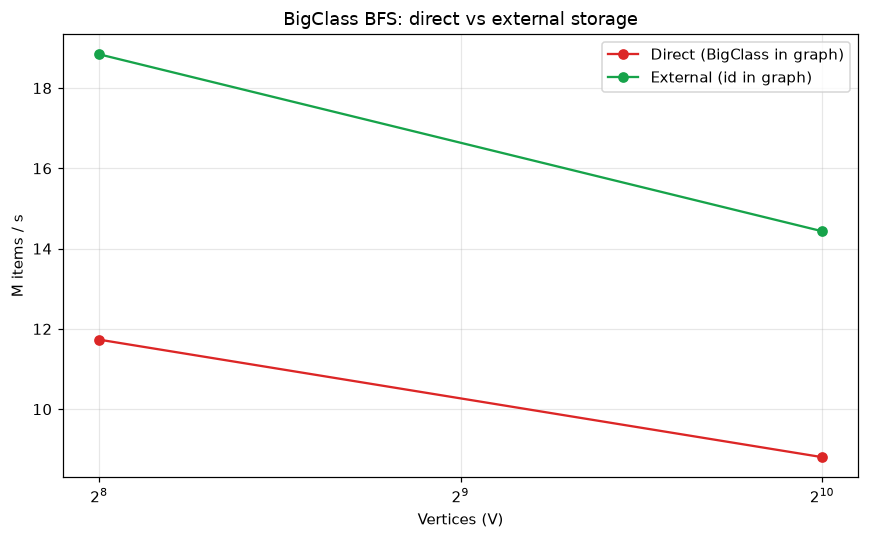

In [24]:
bc = df[df["family"].isin(["BM_BigClass_Direct_BFS", "BM_BigClass_External_BFS"])].dropna(subset=["param"])
fig, ax = plt.subplots(figsize=(8, 5))
for fam, lbl, c in [("BM_BigClass_Direct_BFS", "Direct (BigClass in graph)", "#dc2626"),
                    ("BM_BigClass_External_BFS", "External (id in graph)", "#16a34a")]:
    d = bc[bc["family"] == fam].sort_values("param")
    ax.plot(d["param"], d["items_per_second"] / 1e6, marker="o", label=lbl, color=c)
ax.set_xscale("log", base=2)
ax.set_xlabel("Vertices (V)"); ax.set_ylabel("M items / s")
ax.set_title("BigClass BFS: direct vs external storage"); ax.legend()
plt.tight_layout(); plt.show()
